In [1]:
import anndata


In [2]:
import scanpy


In [ ]:
# batches: 85
# samples: 8

# /scratch/c9881013/felix_granada/granada/redeconv/redeconv_atlas/Results_4_normalization/scRNA_seq_new_noShift.tsv
# /scratch/c9881013/felix_granada/granada/redeconv/redeconv_atlas/Results_4_normalization/Meta_data_new.tsv


expr cells: 5314, meta cells: 5314, overlap: 5314


/gpfs/gpfs1/scratch/c9881013/.conda_envs/redeconv-env/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/gpfs/gpfs1/scratch/c9881013/.conda_envs/redeconv-env/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/gpfs/gpfs1/scratch/c9881013/.conda_envs/redeconv-env/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


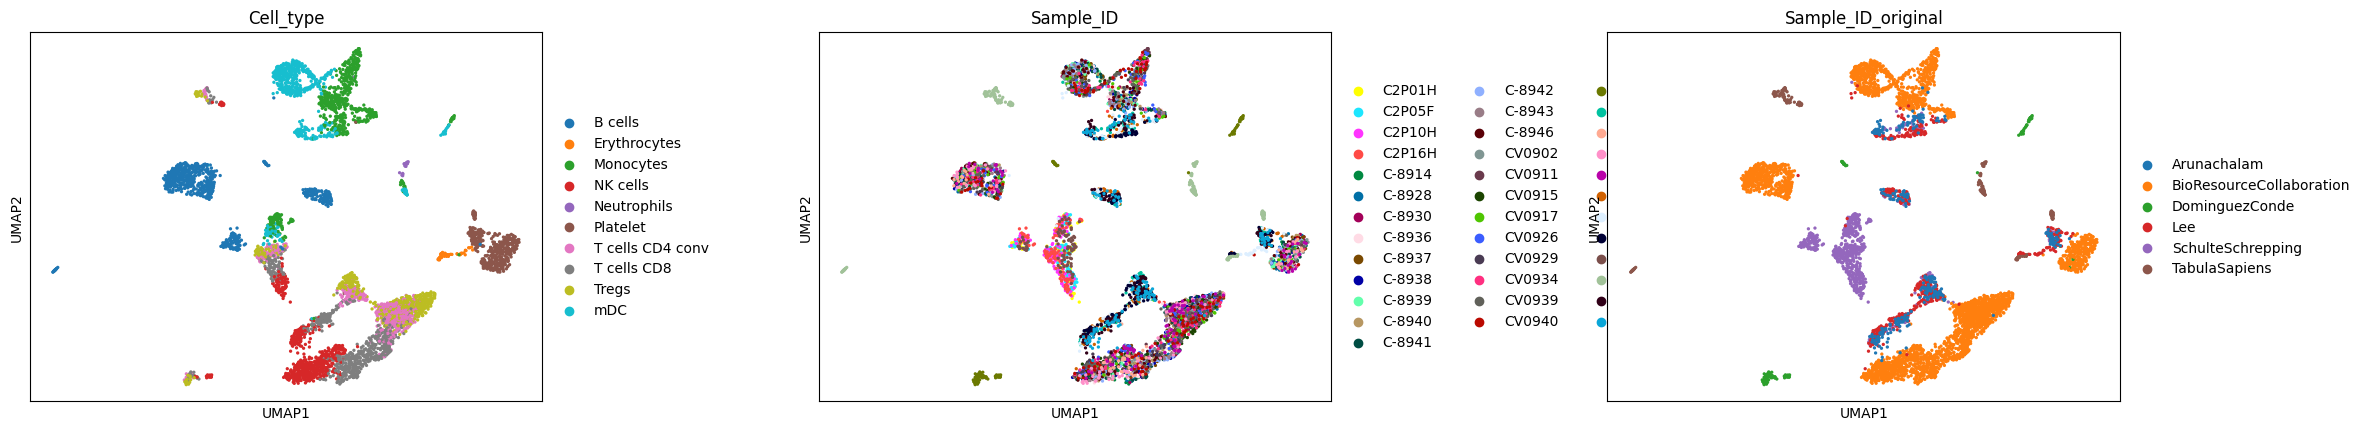

In [8]:
import pandas as pd
import scanpy as sc
import anndata as ad

# Input files (from ReDeconv normalization output)
expr_path = "/scratch/c9881013/felix_granada/granada/redeconv/redeconv_atlas/Results_4_normalization/scRNA_seq_new_noShift.tsv"
meta_path = "/scratch/c9881013/felix_granada/granada/redeconv/redeconv_atlas/Results_4_normalization/Meta_data_new.tsv"
meta_original_path = "/scratch/c9881013/felix_granada/granada/redeconv/redeconv_atlas/demo_data_4_normalization/Demo_ATLAS_meta_original.tsv"

# Load expression: rows=genes, columns=cells, first column is gene id/name
expr = pd.read_csv(expr_path, sep="\t")
expr = expr.set_index(expr.columns[0])
expr.columns = expr.columns.astype(str).str.strip()

# Load metadata and align to expression cell columns
meta = pd.read_csv(meta_path, sep="\t")
meta["Cell_ID"] = meta["Cell_ID"].astype(str).str.strip()
meta = meta.set_index("Cell_ID")

# Add original sample IDs for plotting
meta_orig = pd.read_csv(meta_original_path, sep="\t")[["Cell_ID", "Sample_ID_original"]]
meta_orig["Cell_ID"] = meta_orig["Cell_ID"].astype(str).str.strip()
meta = meta.reset_index().merge(meta_orig, on="Cell_ID", how="left").set_index("Cell_ID")

common_cells = [c for c in expr.columns if c in meta.index]
print(f"expr cells: {len(expr.columns)}, meta cells: {len(meta.index)}, overlap: {len(common_cells)}")
if len(common_cells) == 0:
    raise ValueError("No overlapping cell IDs between expression columns and meta Cell_ID. Check paths/IDs.")

# Build AnnData: rows=cells, cols=genes
adata = ad.AnnData(X=expr[common_cells].T)
adata.obs = meta.loc[common_cells].copy()
adata.obs.index = adata.obs.index.astype(str)
adata.var_names = expr.index.astype(str)

# Standard UMAP pipeline
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=min(2000, adata.n_vars - 1), subset=True)
sc.pp.scale(adata, max_value=10)
sc.tl.pca(adata, svd_solver="arpack")
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=min(30, adata.n_vars - 1))
sc.tl.umap(adata)

# Plot by cell type and sample fields
sc.pl.umap(adata, color=["Cell_type", "Sample_ID", "Sample_ID_original"], wspace=0.4)



RAW expr cells: 11731, RAW meta cells: 11731, overlap: 11731


/gpfs/gpfs1/scratch/c9881013/.conda_envs/redeconv-env/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/gpfs/gpfs1/scratch/c9881013/.conda_envs/redeconv-env/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/gpfs/gpfs1/scratch/c9881013/.conda_envs/redeconv-env/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


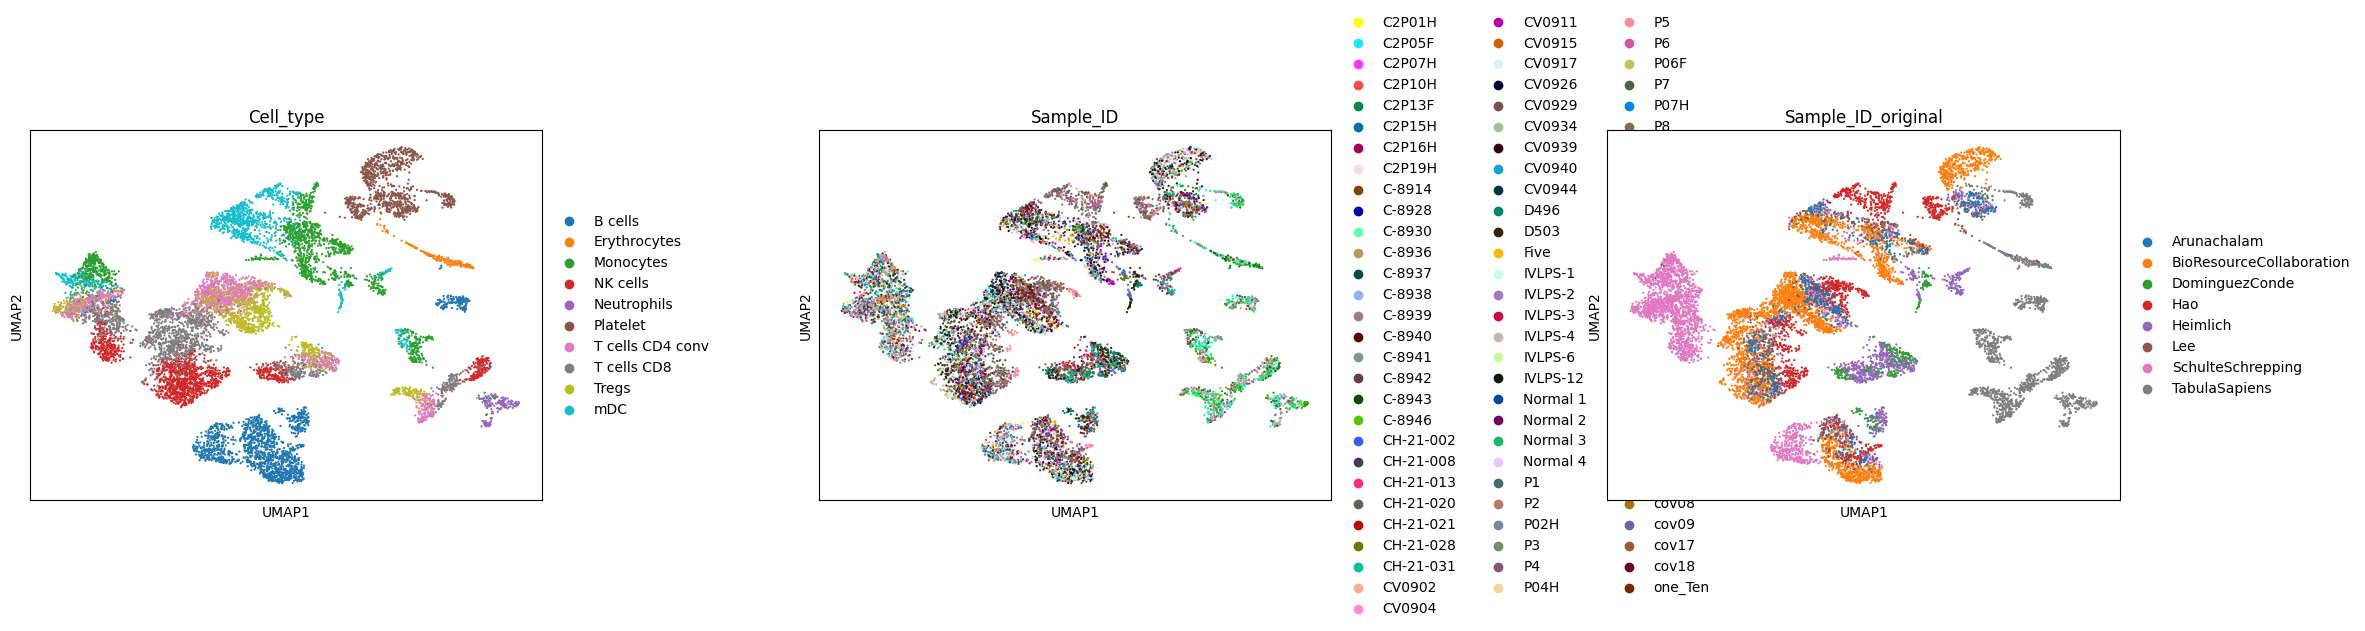

In [9]:
import pandas as pd
import scanpy as sc
import anndata as ad

# Non-normalized atlas input files
expr_path_raw = "/scratch/c9881013/felix_granada/granada/redeconv/redeconv_atlas/demo_data_4_normalization/Demo_ATLAS_scRNAseq.tsv"
meta_path_raw = "/scratch/c9881013/felix_granada/granada/redeconv/redeconv_atlas/demo_data_4_normalization/Demo_ATLAS_meta_original.tsv"

# Load expression: rows=genes, columns=cells, first column is gene id/name
expr_raw = pd.read_csv(expr_path_raw, sep="\t")
expr_raw = expr_raw.set_index(expr_raw.columns[0])
expr_raw.columns = expr_raw.columns.astype(str).str.strip()

# Load metadata and align to expression cell columns
meta_raw = pd.read_csv(meta_path_raw, sep="\t")
meta_raw["Cell_ID"] = meta_raw["Cell_ID"].astype(str).str.strip()
meta_raw = meta_raw.set_index("Cell_ID")

common_cells_raw = [c for c in expr_raw.columns if c in meta_raw.index]
print(f"RAW expr cells: {len(expr_raw.columns)}, RAW meta cells: {len(meta_raw.index)}, overlap: {len(common_cells_raw)}")
if len(common_cells_raw) == 0:
    raise ValueError("No overlapping cell IDs between raw expression columns and raw metadata Cell_ID.")

# Build AnnData: rows=cells, cols=genes
adata_raw = ad.AnnData(X=expr_raw[common_cells_raw].T)
adata_raw.obs = meta_raw.loc[common_cells_raw].copy()
adata_raw.obs.index = adata_raw.obs.index.astype(str)
adata_raw.var_names = expr_raw.index.astype(str)

# Standard UMAP pipeline
sc.pp.normalize_total(adata_raw, target_sum=1e4)
sc.pp.log1p(adata_raw)
sc.pp.highly_variable_genes(adata_raw, n_top_genes=min(2000, adata_raw.n_vars - 1), subset=True)
sc.pp.scale(adata_raw, max_value=10)
sc.tl.pca(adata_raw, svd_solver="arpack")
sc.pp.neighbors(adata_raw, n_neighbors=15, n_pcs=min(30, adata_raw.n_vars - 1))
sc.tl.umap(adata_raw)

# Plot with same metadata fields as normalized run
sc.pl.umap(adata_raw, color=["Cell_type", "Sample_ID", "Sample_ID_original"], wspace=0.4)

